# EDA — Structured, Reproducible, Time-Boxed

**Purpose:** a reusable EDA framework for any tabular data science project, regardless of domain knowledge.

**How this notebook works:**
- Each layer has a **fixed time-box**. If nothing critical is found within that time, write "no relevant findings" and move on.
- Layer 2 (bivariate vs. target) uses **pre-registered hypotheses**: write your expectation *before* plotting, to avoid HARKing (Hypothesizing After the Results are Known).
- Any interesting idea that pops up mid-analysis but is **not** part of the current hypothesis list goes into the **Parking Lot** section, not investigated immediately — unless it threatens model validity (e.g. leakage, broken key).
- Replace placeholders (`df`, `TARGET`, `KEY_COLS`, etc.) with your project's actual names.

---


## 0. Project Contract  `[ ~5 min ]`

Answer these before opening a single plot. This is what tells you *where to stop* in every layer below.

- **Unit of analysis:** *(e.g. one row = one store-day / one customer / one transaction)* → `One processed product per row`
- **Target variable:** → `Machine failure`
- **Business question the model answers:** → `When the machine indicates it has a higher risk of failure so that the maintenance team can properly organize the team to run the maintenance?`
- **Success criterion:** *(e.g. RMSE < X, or "identify top 3 drivers")* → `Recall > 0.6`
- **Is this a time series problem?** (affects whether Section 4 applies) → `No`

### Business Question Quality Check

A weak business question describes the model's **technical output** ("predict sales"). A strong one describes the **decision** someone will make with that output. Before moving to Layer 0b, validate your business question against these 3 components. If you can't fill in all three, the question is still at the "technical output" level — rewrite it first.

| Component | Question to answer | Your answer |
|---|---|---|
| **Who decides what** | Which person/team acts on this output, and what action do they take? *(e.g. store manager reorders stock, maintenance team schedules inspection, restaurant owner prioritizes a fix)* | `___` |
| **Decision granularity** | At what level is the decision made? *(per store? per equipment unit? aggregated across the whole business?)* | `___` |
| **Action horizon** | How soon does the decision need to happen? *(real-time? next week? next quarter?)* | `___` |

**Example — weak vs. strong:**
- Weak: *"Predict daily sales."*
- Strong: *"How much stock should each store receive next week, so the supply chain team avoids both stockouts and overstock?"* → who: supply chain team / granularity: per store / horizon: next week.


In [40]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

# ---- CONFIG: edit these for your project ----
DATA_PATH = "../data/ai4i2020.csv"
TARGET = "Machine failure"
KEY_COLS = ["UDI"]       # column(s) that should uniquely identify a row
DATE_COL = None                      # set to a column name if this is a time series problem, else None

df = pd.read_csv(DATA_PATH)
df.shape


(10000, 14)

## 0b. Structural Sanity Check (Layer 0)  `[ time-box: 15 min ]`

**Goal:** confirm the data actually matches its expected structure — before you interpret anything.

**What to check / why it matters / how to detect it:**

| Check | Why it matters | How to detect |
|---|---|---|
| Shape & dtypes | Wrong dtype silently breaks aggregations later | `df.dtypes` |
| Key uniqueness | Duplicate keys corrupt joins and groupbys downstream | `df.duplicated(subset=KEY_COLS).sum()` |
| Missingness | Some models fail silently on NaN; missingness itself can be a signal | `df.isnull().mean()` |
| Cardinality of categoricals | Abnormally high cardinality is usually a **bug** (encoding inconsistency), not a domain fact — this you can catch with zero domain knowledge | `df[col].nunique()` |

**Exit criterion:** either you found a structural issue (fix it now, it's cheap) or you didn't (write "clean" and move on — do not keep staring at this).


In [24]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nDuplicate full rows:", df.duplicated().sum())
print("Duplicate keys:", df.duplicated(subset=KEY_COLS).sum() if KEY_COLS else "KEY_COLS not set")


Shape: (10000, 14)

Dtypes:
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Duplicate full rows: 0
Duplicate keys: 0


In [25]:
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: float64)

In [26]:
# Cardinality scan — flags potential encoding bugs disguised as "high-cardinality categories"
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for c in cat_cols:
    print(f"{c:30s} nunique={df[c].nunique():6d}  top_value_share={df[c].value_counts(normalize=True).iloc[0]:.2%}")


Product ID                     nunique= 10000  top_value_share=0.01%
Type                           nunique=     3  top_value_share=60.00%


**Findings (fill in):**
- [x] Key uniqueness: `No problems found`
- [x] Suspicious missing values (e.g. a placeholder like -999 or "unknown"): `The dataset does not have missing values`
- [x] Cardinality anomalies: `Looks good. Just confirmed that *Type* feature has 60%, 30%, and 10%.`


## 1. Univariate Analysis (Layer 1)  `[ time-box: 30 min ]`

**Goal:** does each variable make sense *on its own*? Not looking at the target yet.

**Common mistake:** trusting `.describe()` alone. A mean can look perfectly reasonable while hiding bimodality — always plot the distribution, don't just read the summary stats (classic Anscombe's Quartet lesson).


In [27]:
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
UDI,10000.0,5000.50000,2886.895680,1.0,100.99,500.95,2500.75,5000.5,7500.25,9500.05,9900.01,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,295.90,297.10,298.30,300.1,301.50,303.50,304.10,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,306.60,307.70,308.80,310.1,311.10,312.50,313.20,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1275.00,1332.00,1423.00,1503.0,1612.00,1868.05,2188.01,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,16.70,23.50,33.20,40.1,46.80,56.10,62.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,0.00,9.95,53.00,108.0,162.00,206.05,222.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.00,0.00,0.0,0.00,0.00,1.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.00,0.00,0.0,0.00,0.00,1.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,1.0


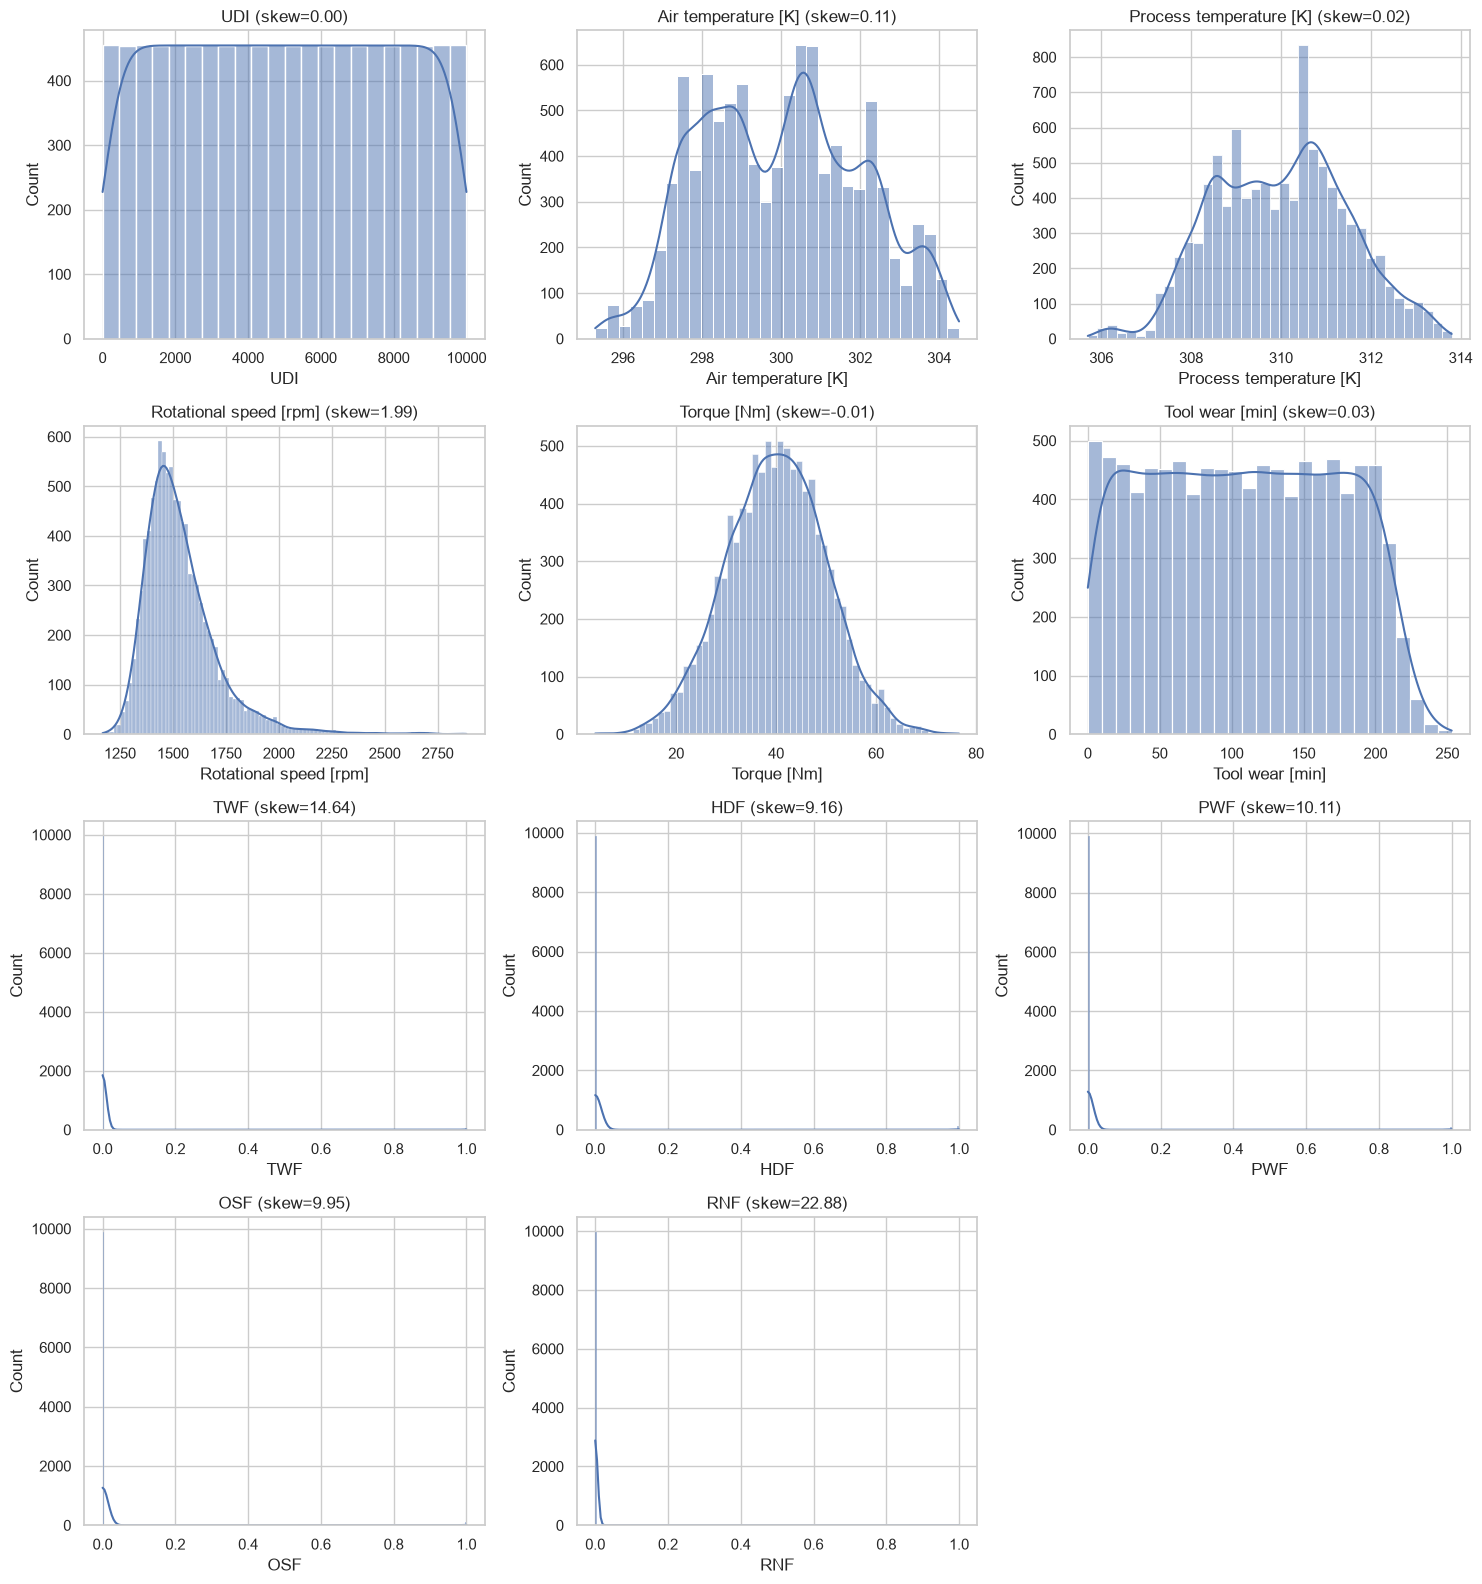

In [28]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

n = len(num_cols)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(15, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (skew={df[col].skew():.2f})")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**What to look for:**
- `|skew| > 1` → candidate for transformation (log, Box-Cox)
- Isolated extreme values far outside P1–P99 → often a disguised missing-value code (e.g. `-999`), not a real observation
- Near-constant categorical (one category > 95% share) → low predictive power on its own, but don't discard yet — check Layer 2 first


In [29]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).head(10))



--- Product ID ---
Product ID
M14860    0.0001
L47181    0.0001
L47182    0.0001
L47183    0.0001
L47184    0.0001
M14865    0.0001
L47186    0.0001
L47187    0.0001
M14868    0.0001
M14869    0.0001
Name: proportion, dtype: float64

--- Type ---
Type
L    0.6000
M    0.2997
H    0.1003
Name: proportion, dtype: float64


**Findings (fill in):**
- Variables needing transformation: `Rotational speed`
- Suspicious placeholder values: `No`
- Near-constant variables: `No`


## 2. Bivariate Analysis vs. Target — Pre-Registered Hypotheses (Layer 2)  `[ time-box: 45 min ]`

**This is the most important layer.** Everything before this was hygiene; this is where you generate real feature-engineering hypotheses.

### Step A — Write your hypothesis list BEFORE plotting anything

For each variable you suspect might matter, fill in this template. If you can't fill all three blanks, you don't have a hypothesis yet, you have curiosity — put it in the **Parking Lot** below instead.

> **Hypothesis:** I expect to see `___`, because `___`.
> If I don't see that, the conclusion is `___`.

Sources for hypotheses when you don't know the domain (all domain-agnostic, structural reasoning):
1. **Trend over time** — does the target drift with a date/time variable?
2. **Magnitude / monotonicity** — does more X consistently mean more or less target?
3. **Heterogeneity by group** — does the X→target relationship change across a categorical variable?
4. **Missingness as signal** — is missingness random, or does it correlate with the target?
5. **Threshold / saturation** — is the effect linear, or does it only kick in past some value?
6. **Interaction** — does the effect of X depend on the value of another variable Z?

You can also use a quick data-driven scan to *point* you toward candidates (not to replace the hypothesis step — write the mechanism hypothesis *after* seeing the scan, *before* plotting):

```python
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X, y)
```

Label clearly in your notes which hypotheses were **reasoning-driven** vs. **data-scan-driven** — the latter carries more risk of being a coincidental pattern.

---

### Hypothesis Log

| # | Variable | Hypothesis (expect / because / if not) | Source (reasoning / data-scan / stakeholder) | Result | Decision |
|---|---|---|---|---|---|
| 1 | `Torque [Nm]` | `Eu espero que possa haver falhas quando o torque estiver alto, por que isso deve forçar além de sua capacidade. Se essa hipótese for falsa ou fraca, deve ser uma falha que não esteja relacionada ao aumento de rotação.` | `___` | `Falhou. Existe falhas em todo o range do torque.` | `___` |
| 2 | `Rotational speed [rpm]` | `Eu espero que as falhas aconteçam quando o RPM estiver alto, por que isso deve forçar além de sua capacidade. Se essa hipótese for falsa ou fraca, deve ser uma falha que não esteja relacionada ao aumento de rotação.` | `___` | `Falhou. Existe falhas em todo o range do torque.` | `___` |
| 3 | `Tool wear [min]` | `Eu espero encontrar falhas quando o desgaste da ferramente aumento, por que ele irá apresentar mais resistência ao corte e isso fará com que a máquina precise de mais torque.` | `___` | `___` | `___` |
| 4 | `Process temperature [K]` | `Eu espero que altas temperaturas no processo gere alguma falha, por que a máquina poderia trabalhar em temperatura acima do permitido.` | `___` | `___` | `___` |
| 5 | `___` | `___` | `___` | `___` | `___` |


In [18]:
multi_target_drop = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df.drop(columns=multi_target_drop)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0


In [31]:
# Optional: data-driven scan to help prioritize which variables to write hypotheses for
# (Use this to point attention, not as a substitute for a mechanism hypothesis)

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

multi_target_drop = ["UDI", 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', TARGET]
scan_df = df.drop(columns=multi_target_drop).copy()

cat_scan_cols = scan_df.select_dtypes(include=['object', 'category']).columns
if len(cat_scan_cols) > 0:
    scan_df[cat_scan_cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)\
        .fit_transform(scan_df[cat_scan_cols].astype(str))
scan_df = scan_df.select_dtypes(include=np.number).fillna(-1)

mi_scores = mutual_info_regression(scan_df, df[TARGET].fillna(df[TARGET].median()))
pd.Series(mi_scores, index=scan_df.columns).sort_values(ascending=False)


Torque [Nm]                0.050943
Rotational speed [rpm]     0.040095
Tool wear [min]            0.020978
Product ID                 0.012257
Air temperature [K]        0.006162
Process temperature [K]    0.003684
Type                       0.000000
dtype: float64

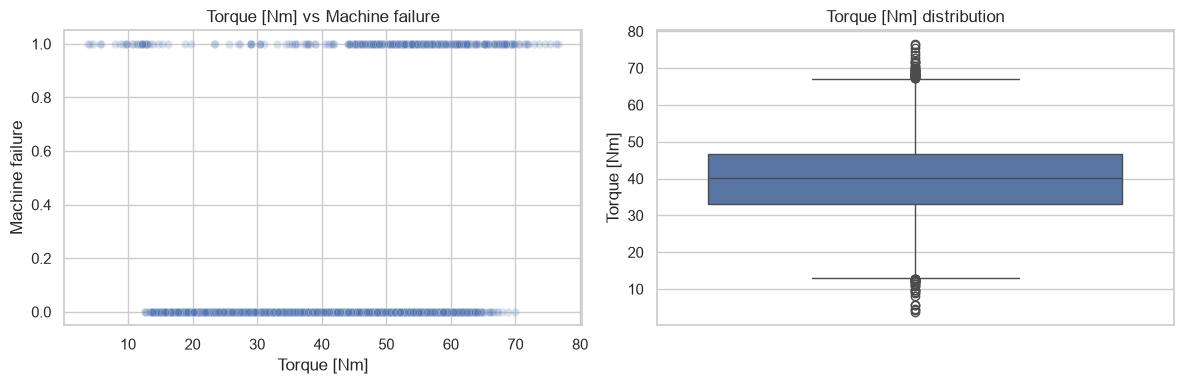

Correlation: 0.1913207750594941


In [32]:
# --- Test Hypothesis #1 ---
# Fill in `col` and re-run this cell per hypothesis (numeric variable vs numeric target)
col = "Torque [Nm]"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df[col], y=df[TARGET], alpha=0.2, ax=ax[0])
ax[0].set_title(f"{col} vs {TARGET}")
sns.boxplot(y=df[col], ax=ax[1])
ax[1].set_title(f"{col} distribution")
plt.tight_layout()
plt.show()

print("Correlation:", df[[col, TARGET]].corr().iloc[0, 1])


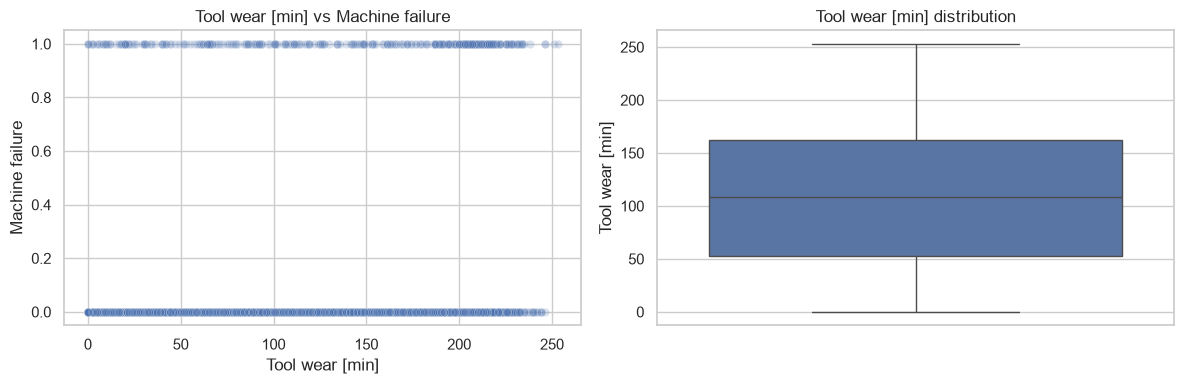

Correlation: 0.1054482189195948


In [38]:
# --- Test Hypothesis #1 ---
# Fill in `col` and re-run this cell per hypothesis (numeric variable vs numeric target)
col = "Tool wear [min]"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df[col], y=df[TARGET], alpha=0.2, ax=ax[0])
ax[0].set_title(f"{col} vs {TARGET}")
sns.boxplot(y=df[col], ax=ax[1])
ax[1].set_title(f"{col} distribution")
plt.tight_layout()
plt.show()

print("Correlation:", df[[col, TARGET]].corr().iloc[0, 1])


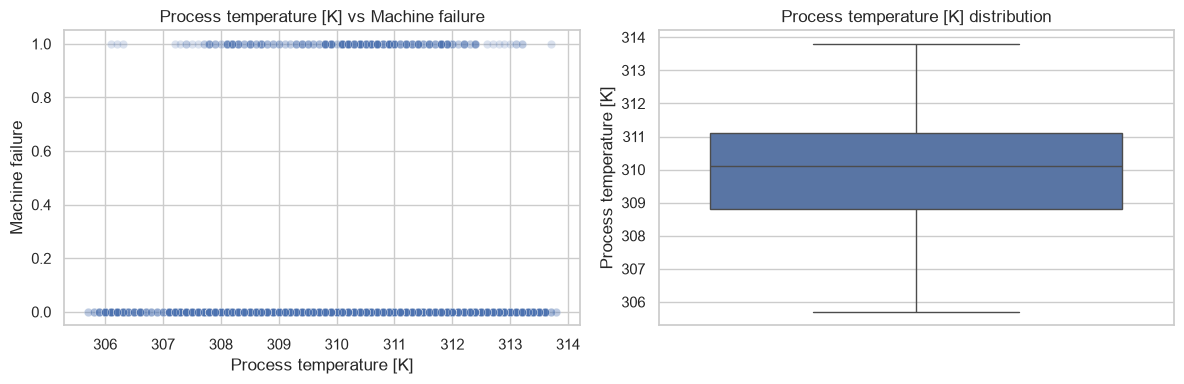

Correlation: 0.03594597332975212


In [39]:
# --- Test Hypothesis #1 ---
# Fill in `col` and re-run this cell per hypothesis (numeric variable vs numeric target)
col = "Process temperature [K]"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df[col], y=df[TARGET], alpha=0.2, ax=ax[0])
ax[0].set_title(f"{col} vs {TARGET}")
sns.boxplot(y=df[col], ax=ax[1])
ax[1].set_title(f"{col} distribution")
plt.tight_layout()
plt.show()

print("Correlation:", df[[col, TARGET]].corr().iloc[0, 1])


,mean,count,std
Type,,,
L,0.039167,6000,0.194008
M,0.027694,2997,0.164123
H,0.020937,1003,0.143246


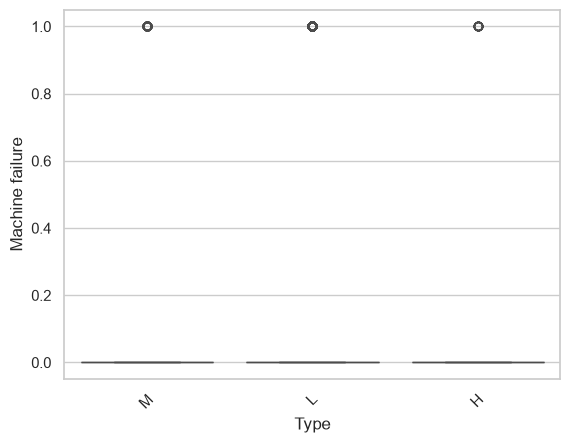

In [34]:
# --- Test Hypothesis (categorical vs numeric target) ---
# Fill in `col` and re-run per categorical hypothesis
col = "Type"

summary = df.groupby(col)[TARGET].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)
display(summary)
# Common mistake: trusting `mean` alone. Always check `count` too —
# a category with a high mean but count=3 is noise, not signal.

sns.boxplot(x=col, y=TARGET, data=df)
plt.xticks(rotation=45)
plt.show()


### Parking Lot — ideas that came up but were NOT part of the pre-registered list

Do not investigate these now. Revisit only if time remains within this layer's time-box, otherwise carry to next iteration / feature engineering backlog.

- `Rotational speed alta + torque baixo`
- `Rotational speed baixa + torque alto`
- `calcular "power" como uma feature derivada de torque × rotational speed`
- `criar uma feature de diferença de temperatura`

**Exception:** if an idea threatens model validity (e.g. suspected leakage, broken key, train/test distribution shift), stop and investigate immediately — that's risk, not curiosity.


## 3. Multivariate Analysis — Redundancy Check (Layer 3)  `[ time-box: 20 min ]`

**Goal:** you already know (Layer 2) which variables matter individually. Now check whether they're duplicating information.

**Note:** for tree-based models (XGBoost, etc.) multicollinearity usually doesn't hurt raw predictive performance, but it *does* distort feature importance / SHAP attribution between the collinear variables. Decide explicitly: do you need prediction only, or prediction + reliable explanation?


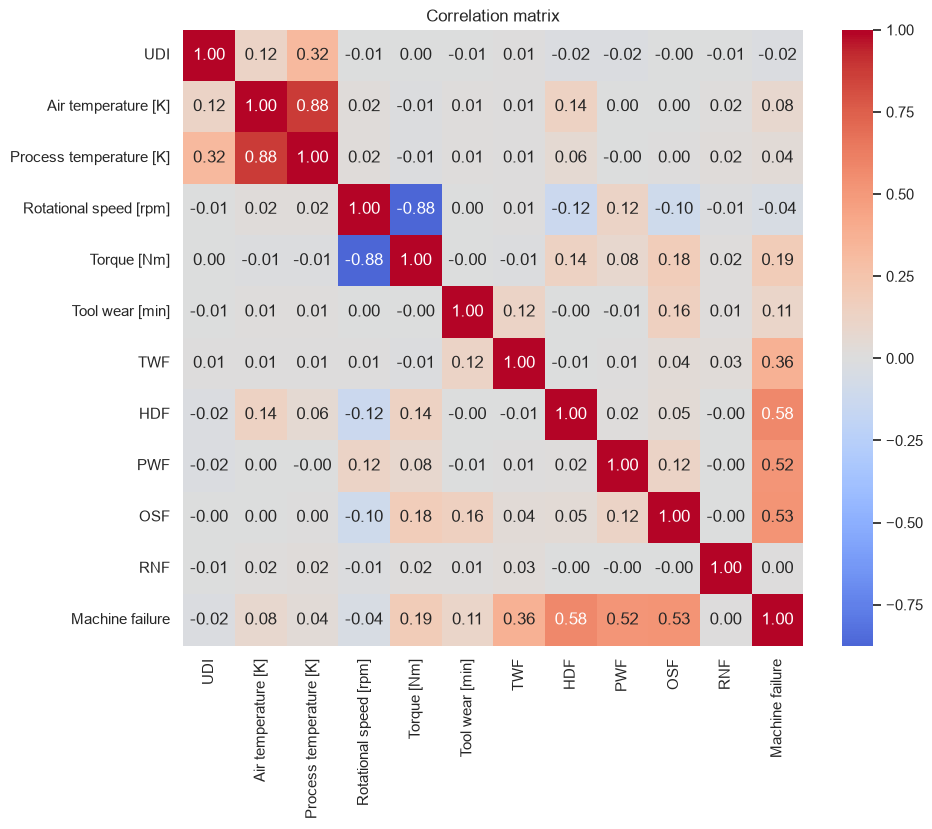

In [35]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_df = add_constant(df[num_cols].fillna(df[num_cols].median()))
vif = pd.Series(
    [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])],
    index=vif_df.columns
).drop('const').sort_values(ascending=False)
vif


Process temperature [K]    5.574046
Torque [Nm]                5.223036
Rotational speed [rpm]     5.155500
Air temperature [K]        5.138815
UDI                        1.292632
PWF                        1.212701
OSF                        1.082741
HDF                        1.062050
Tool wear [min]            1.040210
TWF                        1.015843
RNF                        1.002304
dtype: float64

**Rule of thumb:** VIF > 5–10 → concerning multicollinearity. Correlation between two features > 0.9 → consider dropping one or combining them.

**Findings (fill in):**
- Redundant pairs found: `Air temperature [K] and Process temperature [K]`
- Decision (drop / combine / keep for tree model but flag for SHAP interpretation): `(Maybe) Air temperature [K]`


## 4. Time Series Module (Layer 4) — only if `DATE_COL` is set  `[ time-box: 20 min ]`

Skip this whole section if the project is not a time series problem.


In [ ]:
if DATE_COL is not None:
    ts = df.groupby(DATE_COL)[TARGET].mean()
    plt.figure(figsize=(14, 4))
    ts.plot()
    plt.title(f"{TARGET} over time")
    plt.show()
else:
    print("DATE_COL not set — skipping time series module.")


In [ ]:
if DATE_COL is not None:
    from statsmodels.tsa.seasonal import seasonal_decompose

    # Decide additive vs multiplicative via: visual inspection -> Box-Cox lambda -> residual comparison
    decomposition = seasonal_decompose(ts, model='additive', period=7)  # adjust period to your data's cycle
    decomposition.plot()
    plt.show()


**Critical check — temporal leakage:** for every feature, ask: *"Would this value actually be known at prediction time, or does it leak information from the future?"* This is the most expensive and easiest-to-miss mistake in time series EDA — it often looks like a perfectly normal column in the table.

**Findings (fill in):**
- Trend / seasonality observed: `___`
- Decomposition type chosen and why: `___`
- Leakage risks identified: `___`
- Stationarity (ADF test) if relevant: `___`


## 5. Train vs. Test/Production Distribution Shift  `[ time-box: 10 min ]`

The #1 cause of "great validation score, terrible production performance". Quick and cheap to check, always worth doing.


In [51]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=multi_target_drop)
y = df[TARGET]

train_df, test_df, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
train_df

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
9254,L56434,L,298.3,309.1,1616,31.1,195
1561,L48741,L,298.2,308.4,1388,53.8,137
1670,L48850,L,298.2,307.8,1528,31.1,194
6087,M20947,M,300.9,310.8,1599,33.0,7
6669,L53849,L,301.4,310.5,1571,33.9,208
...,...,...,...,...,...,...,...
5734,L52914,L,302.3,311.8,1369,56.2,208
5191,L52371,L,304.0,313.2,1416,46.0,128
5390,H34804,H,302.8,312.3,1483,47.2,223
860,H30274,H,296.1,306.9,1541,32.6,33


In [61]:
# Example: compare distribution of a feature between train and test sets
# from scipy.stats import ks_2samp

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
num_cols = train_df.select_dtypes(include=numerics).columns

for col in num_cols:
    if col not in train_df.columns:
        continue

    stat, p_value = ks_2samp(train_df[col], test_df[col])
    # p_value < 0.05 suggests a significant distribution shift for that feature

    print(f"Col: {col} --> {p_value}")

Col: Air temperature [K] --> 0.7564768244124629
Col: Process temperature [K] --> 0.9477629665709796
Col: Rotational speed [rpm] --> 0.606244874851325
Col: Torque [Nm] --> 0.2367945885507641
Col: Tool wear [min] --> 0.21339197123036224


## 6. EDA Summary & Decision Log

Close every EDA session with this. This is what actually gets carried forward into feature engineering and modeling — not the notebook itself.

**Structural issues found and fixed:**
- `___`

**Confirmed hypotheses (strong signal, promising features):**
- `___`

**Rejected hypotheses (documented, not wasted — prevents re-investigating later):**
- `___`

**Parking lot items deferred to next iteration:**
- `___`

**Risks flagged for modeling (leakage, distribution shift, multicollinearity, etc.):**
- `___`

**Total time spent vs. time-boxed target:** `___`
